In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [7]:
df = pd.read_csv("../data/it-service-ticket-classification-dataset/all_tickets_processed_improved_v3.csv")
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


Nombre de tickets : 47837
Catégories : ['Hardware' 'Access' 'Miscellaneous' 'HR Support' 'Purchase'
 'Administrative rights' 'Storage' 'Internal Project']
Distribution :
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


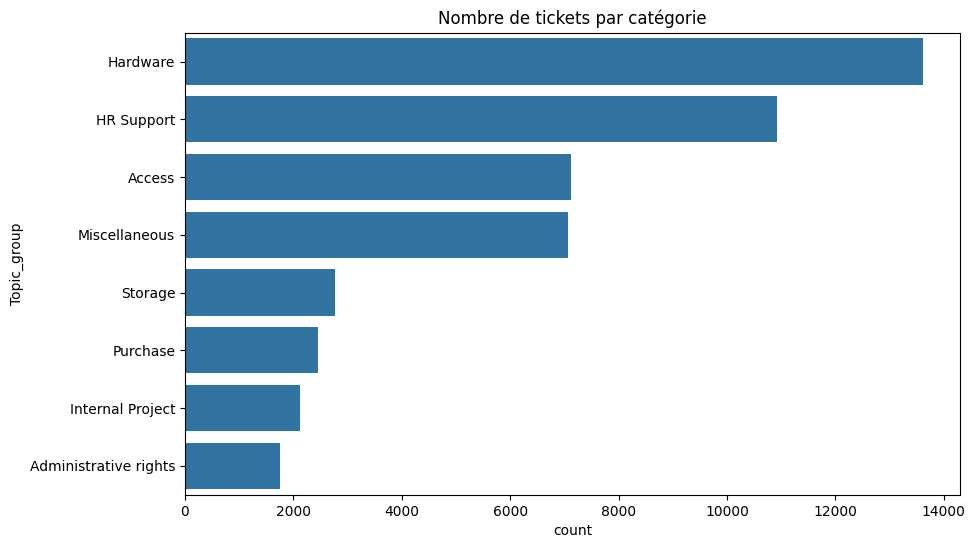

In [9]:
#Statistique de base
print("Nombre de tickets :", len(df))
print("Catégories :", df['Topic_group'].unique())
print("Distribution :")
print(df['Topic_group'].value_counts())

plt.figure(figsize=(10,6))
sns.countplot(y='Topic_group', data=df, order=df['Topic_group'].value_counts().index)
plt.title("Nombre de tickets par catégorie")
plt.show()

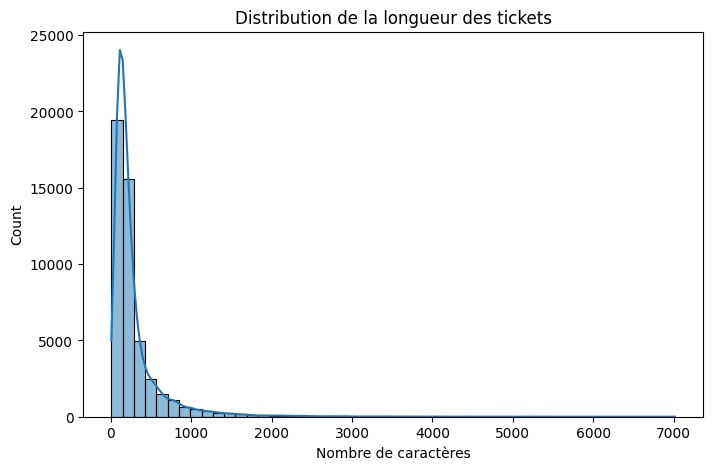

In [10]:
#Longuer de texte 
df['text_length'] = df['Document'].str.len()

plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title("Distribution de la longueur des tickets")
plt.xlabel("Nombre de caractères")
plt.show()

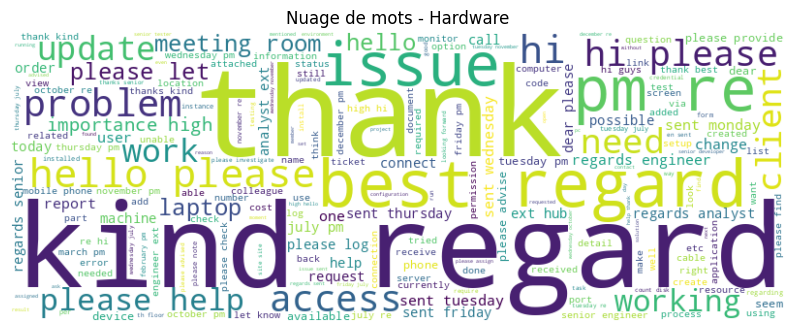

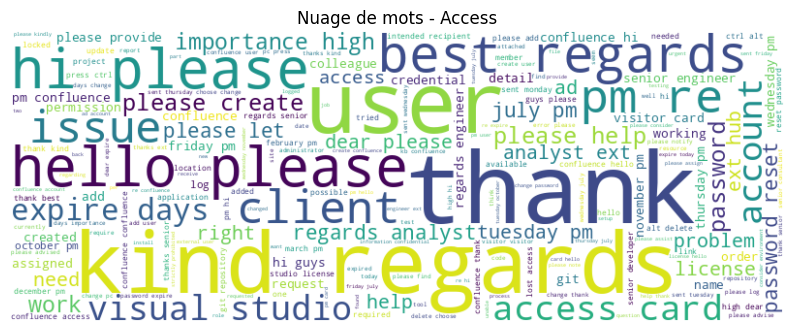

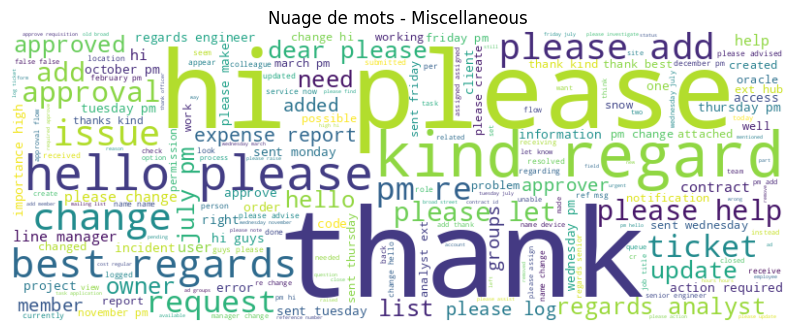

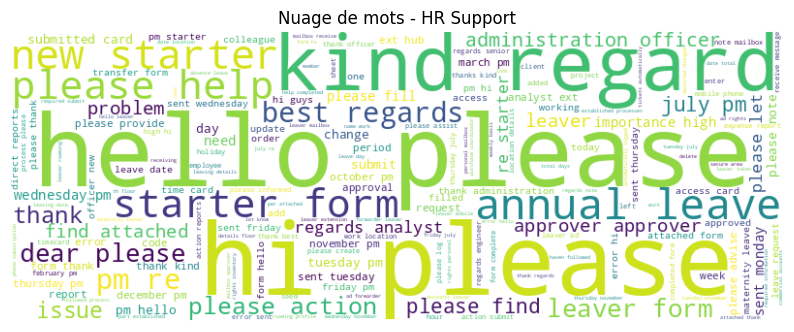

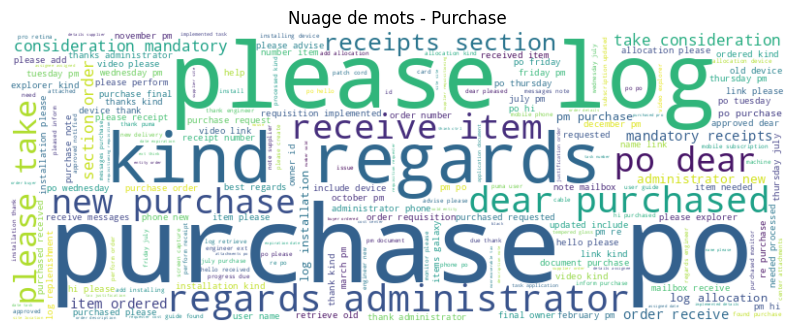

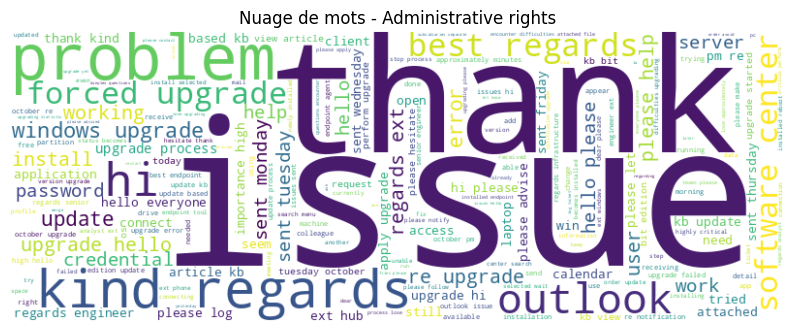

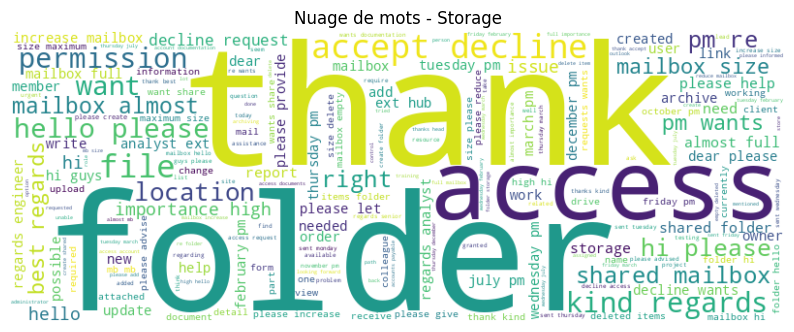

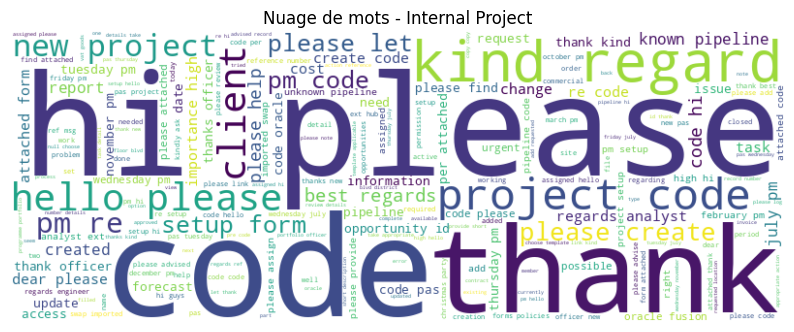

In [14]:
#Nuage de mots (“Wordcloud”) par catégorie
for cat in df['Topic_group'].unique():
    text = " ".join(df[df['Topic_group'] == cat]['Document'].dropna())
    wc = WordCloud(width=800, height=300, background_color='white').generate(text)
    plt.figure(figsize=(10,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Nuage de mots - {cat}")
    plt.show()

In [15]:
#Valeurs manquantes et nettoyage de base
print(df.isnull().sum())

# Optionnel : Supprime les lignes sans texte
df = df.dropna(subset=['Document'])

Document       0
Topic_group    0
text_length    0
dtype: int64


In [16]:
cat_stats = df.groupby('Topic_group')['text_length'].agg(['mean', 'std', 'min', 'max', 'count'])
print(cat_stats)

                             mean         std  min   max  count
Topic_group                                                    
Access                 242.338667  332.337841   15  6363   7125
Administrative rights  339.182955  440.186557   21  6880   1760
HR Support             249.252313  284.265475   13  5595  10915
Hardware               375.408240  516.261347    7  7015  13617
Internal Project       250.317603  300.303126   25  5206   2119
Miscellaneous          286.876487  357.805191    7  6912   7060
Purchase               244.642857  183.094747   16  2827   2464
Storage                233.347137  292.040572   27  3021   2777


In [18]:
#exemple de ticket par catégorie
for cat in df['Topic_group'].unique():
    print(f"Exemple pour {cat} :")
    print(df[df['Topic_group'] == cat]['Document'].iloc[0])
    print("-----")

Exemple pour Hardware :
connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead
-----
Exemple pour Access :
work experience user work experience user hi work experience student coming next his name much appreciate him duration thank
-----
Exemple pour Miscellaneous :
mail verification warning hi has got attached please addresses best regards monitoring analyst verification warning
-----
Exemple pour HR Support :
access request dear modules report report cost thank much regards
-----
Exemple pour Purchase :
system hello movement has left available device please kind device denmark copenhagen denmark please source quotation shipping by lead
-----
Exemple pour Administrative rights :
notification wireless devices upgrade cr medium wireless devices upgrade cr medium hi please announce users about window wireless best regards senior engineer cr medium has by hello summary software upgrade release has approved by please wait until compl